In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
import joblib

 

In [19]:
# Load the dataset
print("Loading data...")
df = pd.read_csv('Fraud.csv')
print(f"Data loaded successfully. Shape: {df.shape}")

Loading data...
Data loaded successfully. Shape: (6362620, 11)


In [26]:
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0.0,9839.64,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0.0,1864.28,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,0.0,181.00,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,0.0,21363.00,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0.0,11668.14,False,False,True,False


In [27]:
df.columns


Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'errorBalanceOrig', 'errorBalanceDest',
       'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER'],
      dtype='object')

In [28]:
df.dtypes

step                  int64
amount              float64
oldbalanceOrg       float64
newbalanceOrig      float64
oldbalanceDest      float64
newbalanceDest      float64
isFraud               int64
errorBalanceOrig    float64
errorBalanceDest    float64
type_CASH_OUT          bool
type_DEBIT             bool
type_PAYMENT           bool
type_TRANSFER          bool
dtype: object

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 13 columns):
 #   Column            Dtype  
---  ------            -----  
 0   step              int64  
 1   amount            float64
 2   oldbalanceOrg     float64
 3   newbalanceOrig    float64
 4   oldbalanceDest    float64
 5   newbalanceDest    float64
 6   isFraud           int64  
 7   errorBalanceOrig  float64
 8   errorBalanceDest  float64
 9   type_CASH_OUT     bool   
 10  type_DEBIT        bool   
 11  type_PAYMENT      bool   
 12  type_TRANSFER     bool   
dtypes: bool(4), float64(7), int64(2)
memory usage: 461.2 MB


In [30]:
print(df.isnull().sum())

step                0
amount              0
oldbalanceOrg       0
newbalanceOrig      0
oldbalanceDest      0
newbalanceDest      0
isFraud             0
errorBalanceOrig    0
errorBalanceDest    0
type_CASH_OUT       0
type_DEBIT          0
type_PAYMENT        0
type_TRANSFER       0
dtype: int64


In [31]:
# for understanding target veriable
# how many no of frauds
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [32]:
# calculate fraud percentage
fraud_percentage=(df['isFraud'].sum() / len(df))*100
fraud_percentage

np.float64(0.12908204481801522)

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 

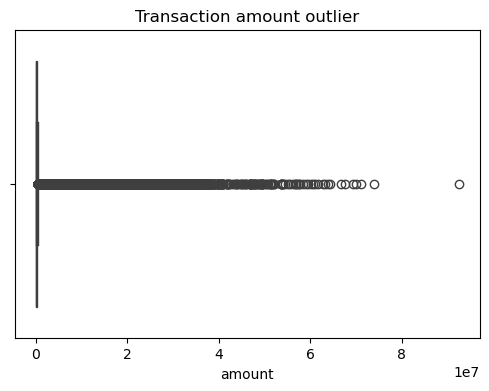

In [41]:
# transac# outlier detection
plt.figure(figsize=(6,4))
sns.boxplot(x=df['amount'])
plt.title('Transaction amount outlier')
plt.show() 
 

In [42]:
# balance based feature check
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest'] - df['amount']


In [43]:
df[['balance_diff_orig','balance_diff_dest']].head()

,balance_diff_orig,balance_diff_dest
0,1.455192e-11,-9839.64
1,-1.136868e-12,-1864.28
2,0.000000e+00,-181.00
3,0.000000e+00,-21363.00
4,0.000000e+00,-11668.14


In [44]:
df[['balance_diff_orig','balance_diff_dest']].describe()

,balance_diff_orig,balance_diff_dest
count,6.362620e+06,6.362620e+06
mean,-2.010925e+05,-5.556717e+04
std,6.066505e+05,4.415288e+05
min,-9.244552e+07,-1.319123e+07
25%,-2.496411e+05,-2.935305e+04
50%,-6.867726e+04,-3.500490e+03
75%,-2.954230e+03,0.000000e+00
max,1.000000e-02,7.588573e+07


In [46]:
# understanding feature types and separate columns types

numerical_cols = [
    'step', 'amount',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest'
]

categorical_cols = ['type']

identifier_cols = ['nameOrig', 'nameDest']

target_col = 'isFraud'


<Figure size 1000x600 with 0 Axes>

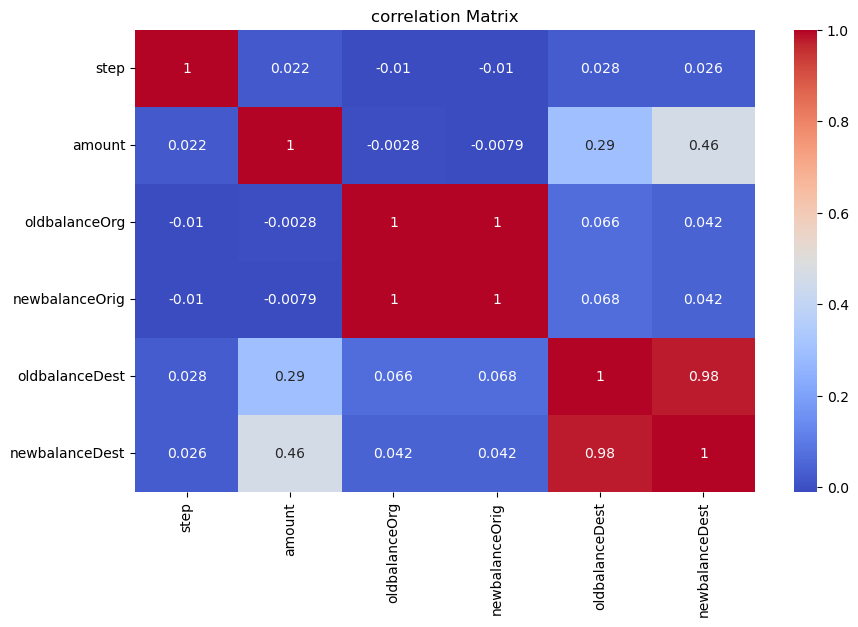

In [47]:
# Multicollinearity
# correlation Matrix
plt.figure(figsize=(10,6))
sns.heatmap(df[numerical_cols].corr(),annot=True,cmap='coolwarm')
plt.title("correlation Matrix")
plt.show()

In [20]:
print("Engineering features...")

# 1. Calculate the mathematical errors in the balances
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# 2. Drop irrelevant columns
# 'nameOrig' and 'nameDest' are strings/identifiers. 
# 'isFlaggedFraud' is a static, inaccurate rule from the original dataset.
df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'], inplace=True)

# 3. One-Hot Encode the 'type' column (CASH_OUT, TRANSFER, etc.)
df = pd.get_dummies(df, columns=['type'], drop_first=True)

print(f"Feature engineering complete. New shape: {df.shape}")

Engineering features...
Feature engineering complete. New shape: (6362620, 13)


In [21]:
print("Splitting data...")
X = df.drop(columns=['isFraud'])
y = df['isFraud']

# 70% for training, 30% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Delete the original dataframe to free up RAM!
 
print("Data split complete.")

Splitting data...
Data split complete.


In [22]:
print("Training HistGradientBoostingClassifier...")

# Initialize the model
# We do NOT use class_weight='balanced' to protect our precision!
hgb_model = HistGradientBoostingClassifier(
    max_iter=100,          # Number of boosting iterations (trees)
    max_depth=12,          # Keep trees from growing too deep
    learning_rate=0.1,     # Standard learning rate
    random_state=42
)

# Fit the model
hgb_model.fit(X_train, y_train)
print("Model training complete.")

Training HistGradientBoostingClassifier...
Model training complete.


In [23]:
print("Evaluating model...")

# Generate predictions
y_pred = hgb_model.predict(X_test)
y_pred_proba = hgb_model.predict_proba(X_test)[:, 1]

# 1. Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(f"True Negatives: {cm[0][0]} (Legitimate transactions approved)")
print(f"False Positives: {cm[0][1]} (Legitimate transactions blocked - WE WANT THIS LOW)")
print(f"False Negatives: {cm[1][0]} (Fraud missed)")
print(f"True Positives: {cm[1][1]} (Fraud caught)")

 

Evaluating model...

--- Confusion Matrix ---
[[1906304      18]
 [      9    2455]]
True Negatives: 1906304 (Legitimate transactions approved)
False Positives: 18 (Legitimate transactions blocked - WE WANT THIS LOW)
False Negatives: 9 (Fraud missed)
True Positives: 2455 (Fraud caught)



--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.99      1.00      0.99      2464

    accuracy                           1.00   1908786
   macro avg       1.00      1.00      1.00   1908786
weighted avg       1.00      1.00      1.00   1908786


--- PR-AUC Score: 0.9952 ---


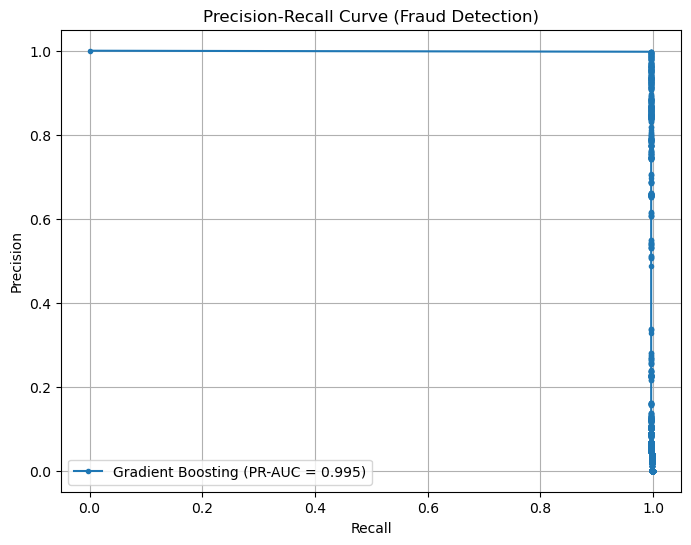

In [24]:
# 2. Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 3. Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)
print(f"\n--- PR-AUC Score: {pr_auc:.4f} ---")

# 4. Plot the PR Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'Gradient Boosting (PR-AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Fraud Detection)')
plt.legend()
plt.grid(True)
plt.show()

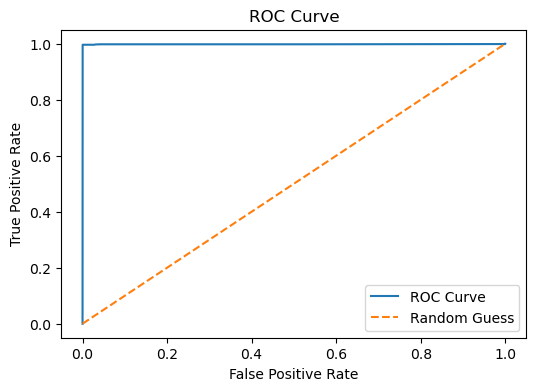

In [49]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], '--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()


In [25]:
import os

print("Saving model...")
os.makedirs("models", exist_ok=True)

# Save the trained model
joblib.dump(hgb_model, "models/fraud_hgb_model.pkl")
print("Model saved successfully in the 'models' folder!")

Saving model...
Model saved successfully in the 'models' folder!
